In [1]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import torchvision.models as models
import torch.nn as nn

from src.MyDataset import MyDataset
from configs.config import *

c:\Users\user\anaconda3\envs\imageClassification\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
transform = transforms.Compose([
    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [3]:
test_set = MyDataset(TEST_CSV, TEST_IMG_DIR, transform=transform)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [4]:
classes = ("apple", "banana", "orange", "pineapple", "watermelon")

In [5]:
net = models.resnet18(weights=None)

net.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(512,5)
)

net.load_state_dict(
    torch.load(MODEL_PATH, weights_only=True)
)

net.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [6]:
correct = 0
total = 0

all_labels = []
all_outputs = []

net.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = net(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_outputs.extend(predicted.cpu().numpy().tolist())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


print(
    f'Accuracy of the network on the {total} test images: '
    f'{100 * correct / total:.2f}%'
)

Accuracy of the network on the 499 test images: 97.19%


In [7]:
accuracy = 100 * correct / total

experiment_path = f"./experiments/{MODEL_NAME}.txt"

with open(experiment_path, "a") as f:
    f.write(
        f"\n\nFinal Test Accuracy:\n{accuracy:.2f}%"
    )

print("Accuracy added to experiment file")

Accuracy added to experiment file


[[96  0  2  1  0]
 [ 2 95  3  0  0]
 [ 1  1 98  0  0]
 [ 0  0  1 99  0]
 [ 0  0  1  2 97]]


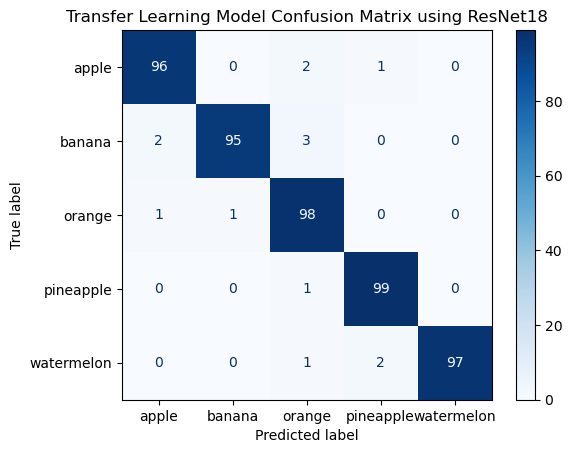

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make sure labels are normal integers
all_labels = [int(x) for x in all_labels]
all_outputs = [int(x) for x in all_outputs]

# Create confusion matrix
cm = confusion_matrix(
    all_labels,
    all_outputs
)

print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Transfer Learning Model Confusion Matrix using ResNet18")
plt.show()